<a href="https://colab.research.google.com/github/gkambasta/TimeSeries/blob/main/Copy_of_StartTS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

plt.rcParams["figure.figsize"] = (9,6)

In [2]:
df = pd.read_csv("/content/monthly-milk-production-pounds.csv")

In [3]:
df.columns = ['Month', 'Milk']
df.head(2)

,Month,Milk
0,1962-01,589
1,1962-02,561


In [4]:
df.Month.tail(3)

,Month
165,1975-10
166,1975-11
167,1975-12


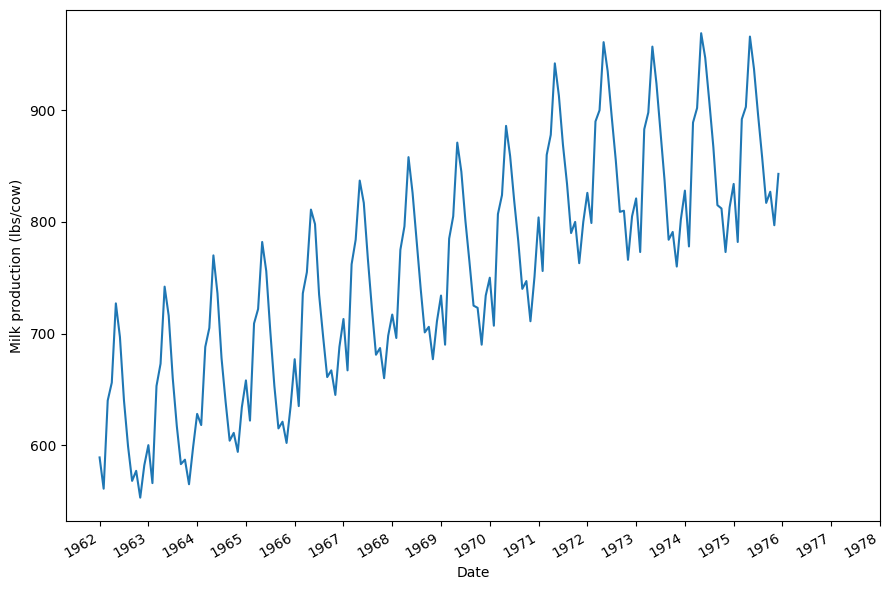

In [5]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Milk'])
ax.set_xlabel('Date')
ax.set_ylabel('Milk production (lbs/cow)')

plt.xticks(np.arange(0, 203, 12), np.arange(1962, 1979, 1))

fig.autofmt_xdate()
plt.tight_layout()

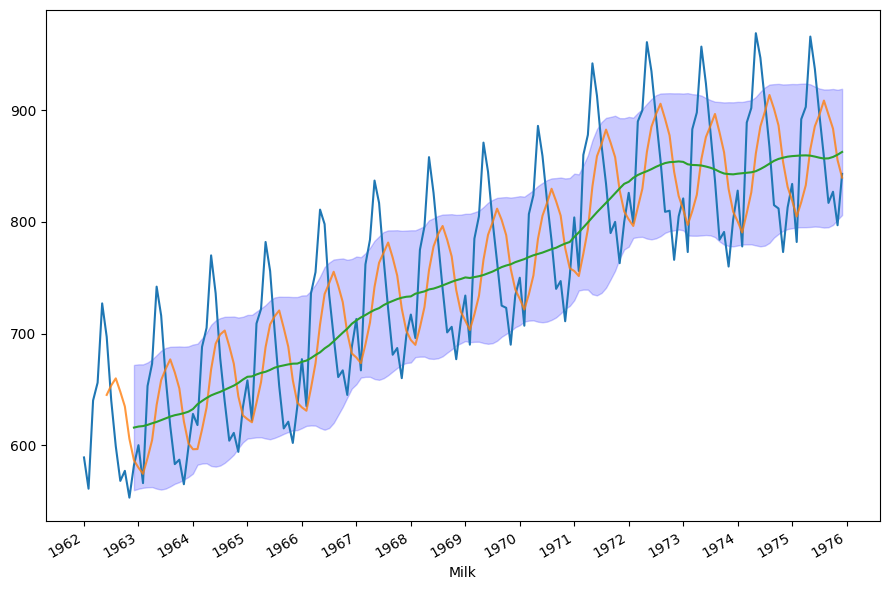

In [6]:
fig, ax = plt.subplots()


ax.plot(df.Month, df.Milk)

ax.set_xlabel ('Milk')
plt.xticks(np.arange(0,179,12), np.arange(1962,1977,1))


roll_mean = df.Milk.rolling(window=6).mean()
roll_mean2 = df.Milk.rolling(window=12).mean()
roll_std2 = df.Milk.rolling(window=12).std()

ax.plot(roll_mean, alpha=0.8)
ax.plot(roll_mean2)

ax.fill_between(df.Month, roll_mean2 - roll_std2, roll_mean2 + roll_std2, color='blue', alpha=0.2, label='1 Std Dev')


#ax.errorbar(df.Milk,roll_mean2, yerr = std_dev)
#plt.plot(roll_mean, label='Mean Curve (Rolling)', color='red')
#plt.legend()
#plt.show()


fig.autofmt_xdate()
fig.tight_layout()

In [15]:
train = df[:-12]
test = df[-12:]

In [16]:
train.shape, test.shape

((156, 2), (12, 2))

In [22]:
#pred_df = test.copy()
pred_df['Mean'] = np.mean(train['Milk'])

In [23]:
pred_df

,Month,Milk,Mean
156,1975-01,834,746.403846
157,1975-02,782,746.403846
158,1975-03,892,746.403846
159,1975-04,903,746.403846
160,1975-05,966,746.403846
161,1975-06,937,746.403846
162,1975-07,896,746.403846
163,1975-08,858,746.403846
164,1975-09,817,746.403846
165,1975-10,827,746.403846


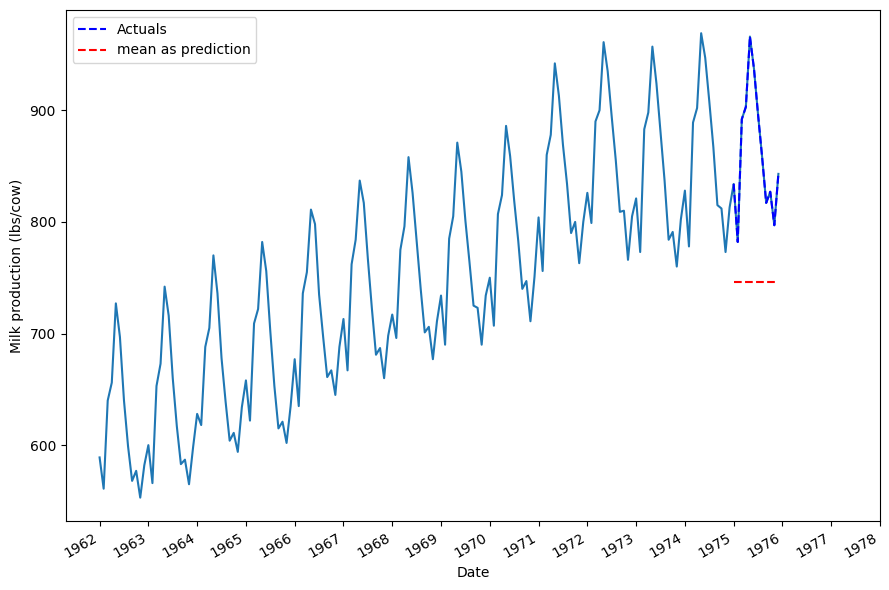

In [35]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Milk'])
ax.set_xlabel('Date')
ax.set_ylabel('Milk production (lbs/cow)')

ax.plot(pred_df['Milk'], "--b", label = "Actuals")
ax.plot(pred_df['Mean'], '--r', label = 'mean as prediction')
ax.legend(loc = 'best')

plt.xticks(np.arange(0, 203, 12), np.arange(1962, 1979, 1))

fig.autofmt_xdate()
plt.tight_layout()

## **AI Generated Code**

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Split the data into training and testing sets (e.g., last 12 months for testing)
train_data = df['Milk'].iloc[:-12]
test_data = df['Milk'].iloc[-12:]

# Define the SARIMA model parameters (p,d,q)(P,D,Q,S)
# These are common initial values for monthly data with trend and seasonality.
# Further analysis (ACF/PACF plots, auto_arima) could refine these.
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 12)

# Instantiate and fit the SARIMA model
model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
results = model.fit()

# Print model summary
print(results.summary())


                                     SARIMAX Results                                      
Dep. Variable:                               Milk   No. Observations:                  156
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -490.963
Date:                            Tue, 07 Apr 2026   AIC                            991.927
Time:                                    11:03:40   BIC                           1006.741
Sample:                                         0   HQIC                           997.947
                                            - 156                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0936      0.315     -0.297      0.766      -0.711       0.524
ma.L1         -0.1724      0.304   

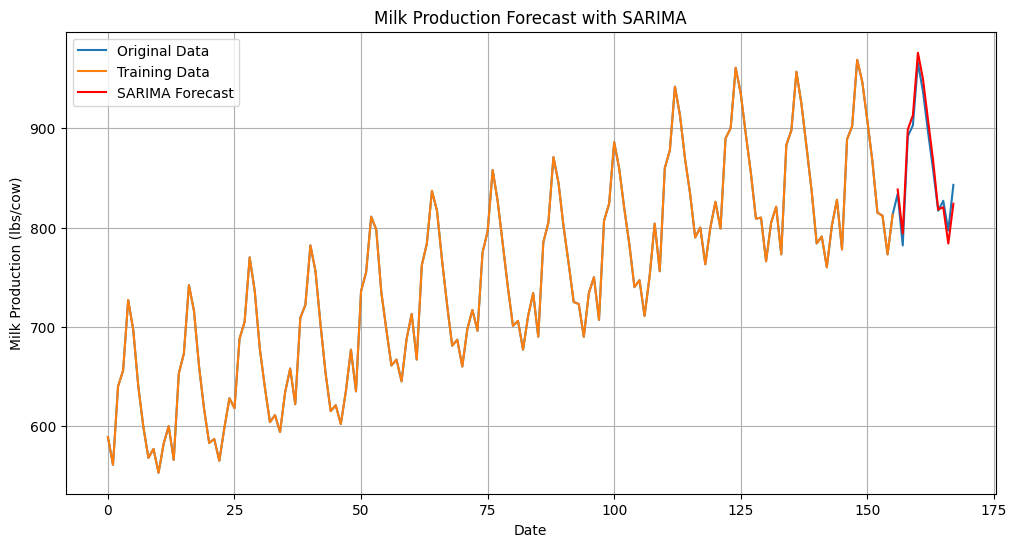

In [8]:
# Generate predictions
start_index = len(train_data)
end_index = len(df['Milk']) - 1
forecast = results.predict(start=start_index, end=end_index, dynamic=False)

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(df['Milk'], label='Original Data')
plt.plot(train_data, label='Training Data')
plt.plot(test_data.index, forecast, label='SARIMA Forecast', color='red')
plt.title('Milk Production Forecast with SARIMA')
plt.xlabel('Date')
plt.ylabel('Milk Production (lbs/cow)')
plt.legend()
plt.grid(True)
plt.show()